In [1]:
import pandas as pd
import numpy as np
import re

In [2]:
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [3]:
df=pd.read_csv('Gurgaon_properties.csv')

In [4]:
df.head(2)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features
0,flat,conscient heritage max,sector 102,1.75,9011.0,1942.0,Super Built up area 1942(180.42 sq.m.),3,4,3+,servant room,13.0,North,1 to 5 Year Old,"['Huda Metro Station', 'Ocus Medley Mall', 'The Esplanade Mall', 'Gurugram Road', 'Dwarka Expy', 'Prime Scholars International School', 'DPG Degree College', 'The Signature Advanced Super Speciality', 'Indira Gandhi Intl Airport', 'Basai Dhankot Railway Station', 'Altrade Business Centre', 'Holiday Inn Gurugram Sector 90', 'SkyJumper Trampoline Park Gurgaon', 'Hamoni Golf Camp', 'Nehru Stadium']","['2 Wardrobe', '4 Fan', '2 Geyser', '1 Stove', '8 Light', '3 AC', '1 Modular Kitchen', '1 Curtains', '1 Chimney', 'No Bed', 'No Dining Table', 'No Exhaust Fan', 'No Microwave', 'No Fridge', 'No Sofa', 'No TV', 'No Washing Machine', 'No Water Purifier']","['Security / Fire Alarm', 'Power Back-up', 'Feng Shui / Vaastu Compliant', 'Intercom Facility', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Swimming Pool', 'Park', 'Internet/wi-fi connectivity', 'Fitness Centre / GYM', 'Waste Disposal', 'Rain Water Harvesting', 'Club house / Community Center', 'Water softening plant']"
1,house,dlf city plots phase 2,sector 25,10.50,261194.0,402.0,Plot area 402(37.35 sq.m.),4,4,2,"pooja room,servant room",2.0,East,10+ Year Old,"['Vodafone belvedere towers metro station', 'Dlf phase 2 metro station', 'Dlf phase 3 metro station', 'Indusind bank cyber city metro station', 'Sikandarpur metro station', 'Shri Shiv Shakthi Mandir', 'Jain Bhawan', 'Arya Samaj Mandir', 'Central bank atm teste 001112', 'Central bank ATM', 'Kotak mahindra ATM', 'Citibank ATM', 'Abn amro bank ATM', 'Axis bank ATM', 'Surgi Center Clinic', 'Kailash Nursing Home Gurgaon', 'RBS Dental Clinic', 'Cosmodentz Dental Clinic', 'Uma Sanjeevani Health Centre And Hospital', 'Relief Physiotherapy Clinic', 'Darpan Skin & Mind Clinic', 'Durga Poly Clinic', 'Krishna Family Clinic', 'Guardian', '98.4', 'Religare Wellness', 'Shri Balaji Medical Store', 'DLF Cyber City Phase II', 'Emaar Business Park', 'Standard chartered bank', 'Icici bank', 'Deutsche bank', 'Hsbc bank', 'Kotak mahindra bank', 'Axis bank', 'PVR Cinames', 'Mukesh Dhaba', 'Mc Donalds', ""McDonald's"", 'Food Court', 'The God Father', 'Cantine', 'barrique', 'American Montessori']","['7 Fan', '1 Exhaust Fan', '4 Geyser', '22 Light', '1 Modular Kitchen', '1 Chimney', '4 Wardrobe', 'No AC', 'No Bed', 'No Curtains', 'No Dining Table', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']","['Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'High Ceiling Height', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Visitor Parking', 'Park', 'Natural Light', 'Airy Rooms', 'Spacious Interiors', 'Low Density Society', 'Waste Disposal', 'Rain Water Harvesting']"


## 1.areaWithType

In [5]:
df.sample(5)[['area','areaWithType']]

,area,areaWithType
2036,900.0,Built Up area: 900 (83.61 sq.m.)
2269,560.0,Super Built up area 560(52.03 sq.m.)
12,476.0,Built Up area: 476 (44.22 sq.m.)
1220,2610.0,Plot area 290(242.48 sq.m.)
3482,2700.0,Super Built up area 3470(322.37 sq.m.)Carpet area: 2700 sq.ft. (250.84 sq.m.)


In [6]:
def get_super_built_up_area(text):
    match = re.search(r'Super Built up area (\d+\.?\d*)', text)
    if match:
        return float(match.group(1))
    return None

In [7]:
def get_area(text, area_type):
    match = re.search(area_type + r'\s*:\s*(\d+\.?\d*)', text)
    if match:
        return float(match.group(1))
    return None

In [8]:
def convert_to_sqft(text, area_value):
    if area_value is None:
        return None
    match = re.search(r'{} \((\d+\.?\d*) sq.m.\)'.format(area_value), text)
    if match:
        sq_m_value = float(match.group(1))
        return sq_m_value * 10.7639  # conversion factor from sq.m. to sqft
    return area_value

In [9]:
df['super_built_up_area'] = df['areaWithType'].apply(get_super_built_up_area)
df['super_built_up_area'] = df.apply(lambda x: convert_to_sqft(x['areaWithType'], x['super_built_up_area']), axis=1)

df['built_up_area'] = df['areaWithType'].apply(lambda x: get_area(x, 'Built Up area'))
df['built_up_area'] = df.apply(lambda x: convert_to_sqft(x['areaWithType'], x['built_up_area']), axis=1)

df['carpet_area'] = df['areaWithType'].apply(lambda x: get_area(x, 'Carpet area'))
df['carpet_area'] = df.apply(lambda x: convert_to_sqft(x['areaWithType'], x['carpet_area']), axis=1)

In [10]:
df[['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].sample(5)

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
1092,0.35,flat,539.0,Carpet area: 547 (50.82 sq.m.),NaN,NaN,547.0
3480,2.20,flat,2149.0,Super Built up area 2149(199.65 sq.m.)Built Up area: 1186 sq.ft. (110.18 sq.m.)Carpet area: 1130 sq.ft. (104.98 sq.m.),2149.0,1186.0,1130.0
1145,0.25,flat,600.0,Built Up area: 600 (55.74 sq.m.),NaN,600.0,NaN
2441,1.90,flat,1672.0,Super Built up area 1672(155.33 sq.m.),1672.0,NaN,NaN
548,0.70,flat,591.0,Carpet area: 591 (54.91 sq.m.),NaN,NaN,591.0


In [11]:
df[~((df['super_built_up_area'].isnull()) | (df['built_up_area'].isnull()) | (df['carpet_area'].isnull()))][['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].shape

(530, 7)

In [12]:
df[df['areaWithType'].str.contains('Plot')][['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].head(5)

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
1,10.50,house,402.0,Plot area 402(37.35 sq.m.),NaN,NaN,NaN
5,0.67,house,76.0,Plot area 76(7.06 sq.m.),NaN,NaN,NaN
10,0.50,house,675.0,Plot area 675(62.71 sq.m.)Built Up area: 725 sq.ft. (67.35 sq.m.)Carpet area: 675 sq.ft. (62.71 sq.m.),NaN,725.0,675.0
14,17.00,house,4518.0,Plot area 502(419.74 sq.m.),NaN,NaN,NaN
26,7.00,house,3000.0,Plot area 2400(222.97 sq.m.)Built Up area: 3400 sq.ft. (315.87 sq.m.)Carpet area: 3000 sq.ft. (278.71 sq.m.),NaN,3400.0,3000.0


In [13]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price                    17
price_per_sqft           17
area                     17
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
additionalRoom            0
floorNum                 19
facing                 1021
agePossession             1
nearbyLocations         164
furnishDetails          939
features                575
super_built_up_area    1749
built_up_area          2496
carpet_area            1765
dtype: int64

In [14]:
all_nan_df=df[(df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull())][['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']]

In [15]:
all_nan_df.head()

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
1,10.50,house,402.0,Plot area 402(37.35 sq.m.),NaN,NaN,NaN
5,0.67,house,76.0,Plot area 76(7.06 sq.m.),NaN,NaN,NaN
14,17.00,house,4518.0,Plot area 502(419.74 sq.m.),NaN,NaN,NaN
32,6.00,house,6228.0,Plot area 692(578.6 sq.m.),NaN,NaN,NaN
38,12.00,house,3240.0,Plot area 360(301.01 sq.m.),NaN,NaN,NaN


In [16]:
all_nan_index = df[((df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull()))][['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].index

In [17]:
def extract_plot_area(area_with_type):
    match = re.search(r'Plot area (\d+\.?\d*)', area_with_type)
    if match:
        return float(match.group(1))
    else:
        return None

In [18]:
all_nan_df['built_up_area'] = all_nan_df['areaWithType'].apply(extract_plot_area)

In [19]:
all_nan_df.head()

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
1,10.50,house,402.0,Plot area 402(37.35 sq.m.),NaN,402.0,NaN
5,0.67,house,76.0,Plot area 76(7.06 sq.m.),NaN,76.0,NaN
14,17.00,house,4518.0,Plot area 502(419.74 sq.m.),NaN,502.0,NaN
32,6.00,house,6228.0,Plot area 692(578.6 sq.m.),NaN,692.0,NaN
38,12.00,house,3240.0,Plot area 360(301.01 sq.m.),NaN,360.0,NaN


In [20]:
def convert_scale(row):
    if np.isnan(row['area']) or np.isnan(row['built_up_area']):
        return row['built_up_area']
    else:
        if round(row['area']/row['built_up_area']) == 9.0:
            return row['built_up_area'] * 9
        elif round(row['area']/row['built_up_area']) == 11.0:
            return row['built_up_area'] * 10.7
        else:
            return row['built_up_area']

In [21]:
all_nan_df['built_up_area'] = all_nan_df.apply(convert_scale,axis=1)

In [22]:
all_nan_df.head()

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
1,10.50,house,402.0,Plot area 402(37.35 sq.m.),NaN,402.0,NaN
5,0.67,house,76.0,Plot area 76(7.06 sq.m.),NaN,76.0,NaN
14,17.00,house,4518.0,Plot area 502(419.74 sq.m.),NaN,4518.0,NaN
32,6.00,house,6228.0,Plot area 692(578.6 sq.m.),NaN,6228.0,NaN
38,12.00,house,3240.0,Plot area 360(301.01 sq.m.),NaN,3240.0,NaN


In [23]:
df.update(all_nan_df)

In [24]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features,super_built_up_area,built_up_area,carpet_area
0,flat,conscient heritage max,sector 102,1.75,9011.0,1942.0,Super Built up area 1942(180.42 sq.m.),3,4,3+,servant room,13.0,North,1 to 5 Year Old,"['Huda Metro Station', 'Ocus Medley Mall', 'The Esplanade Mall', 'Gurugram Road', 'Dwarka Expy', 'Prime Scholars International School', 'DPG Degree College', 'The Signature Advanced Super Speciality', 'Indira Gandhi Intl Airport', 'Basai Dhankot Railway Station', 'Altrade Business Centre', 'Holiday Inn Gurugram Sector 90', 'SkyJumper Trampoline Park Gurgaon', 'Hamoni Golf Camp', 'Nehru Stadium']","['2 Wardrobe', '4 Fan', '2 Geyser', '1 Stove', '8 Light', '3 AC', '1 Modular Kitchen', '1 Curtains', '1 Chimney', 'No Bed', 'No Dining Table', 'No Exhaust Fan', 'No Microwave', 'No Fridge', 'No Sofa', 'No TV', 'No Washing Machine', 'No Water Purifier']","['Security / Fire Alarm', 'Power Back-up', 'Feng Shui / Vaastu Compliant', 'Intercom Facility', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Swimming Pool', 'Park', 'Internet/wi-fi connectivity', 'Fitness Centre / GYM', 'Waste Disposal', 'Rain Water Harvesting', 'Club house / Community Center', 'Water softening plant']",1942.0,NaN,NaN
1,house,dlf city plots phase 2,sector 25,10.50,261194.0,402.0,Plot area 402(37.35 sq.m.),4,4,2,"pooja room,servant room",2.0,East,10+ Year Old,"['Vodafone belvedere towers metro station', 'Dlf phase 2 metro station', 'Dlf phase 3 metro station', 'Indusind bank cyber city metro station', 'Sikandarpur metro station', 'Shri Shiv Shakthi Mandir', 'Jain Bhawan', 'Arya Samaj Mandir', 'Central bank atm teste 001112', 'Central bank ATM', 'Kotak mahindra ATM', 'Citibank ATM', 'Abn amro bank ATM', 'Axis bank ATM', 'Surgi Center Clinic', 'Kailash Nursing Home Gurgaon', 'RBS Dental Clinic', 'Cosmodentz Dental Clinic', 'Uma Sanjeevani Health Centre And Hospital', 'Relief Physiotherapy Clinic', 'Darpan Skin & Mind Clinic', 'Durga Poly Clinic', 'Krishna Family Clinic', 'Guardian', '98.4', 'Religare Wellness', 'Shri Balaji Medical Store', 'DLF Cyber City Phase II', 'Emaar Business Park', 'Standard chartered bank', 'Icici bank', 'Deutsche bank', 'Hsbc bank', 'Kotak mahindra bank', 'Axis bank', 'PVR Cinames', 'Mukesh Dhaba', 'Mc Donalds', ""McDonald's"", 'Food Court', 'The God Father', 'Cantine', 'barrique', 'American Montessori']","['7 Fan', '1 Exhaust Fan', '4 Geyser', '22 Light', '1 Modular Kitchen', '1 Chimney', '4 Wardrobe', 'No AC', 'No Bed', 'No Curtains', 'No Dining Table', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']","['Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'High Ceiling Height', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Visitor Parking', 'Park', 'Natural Light', 'Airy Rooms', 'Spacious Interiors', 'Low Density Society', 'Waste Disposal', 'Rain Water Harvesting']",NaN,402.0,NaN
2,flat,dlf new town heights,sector 90,1.95,7150.0,2727.0,Super Built up area 2727(253.35 sq.m.)Carpet area: 2200 sq.ft. (204.39 sq.m.),4,4,3+,"servant room,store room",24.0,North-East,1 to 5 Year Old,"['Manish Gallexie 91', 'NH-8 IMT Manesar', 'RHM Public School', 'Silver Streak Multi Speciality Hospital', 'Airport', 'Holiday Inn Gurugram']","['5 Fan', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Geyser', 'No Modular Kitchen', 'No Light', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']","['Centrally Air Conditioned', 'Water purifier', 'Security / Fire Alarm', 'Power Back-up', 'Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'Intercom Facility', 'Lift(s)', 'High Ceiling 

## 2. additionalRoom

In [25]:
df['additionalRoom'].value_counts()

additionalRoom
not available                                    1483
servant room                                      681
study room                                        240
others                                            217
pooja room                                        161
store room                                         97
study room,servant room                            96
pooja room,servant room                            81
pooja room,study room,servant room,store room      70
servant room,others                                55
pooja room,study room,servant room,others          54
pooja room,study room,servant room                 53
servant room,pooja room                            38
servant room,store room                            30
study room,others                                  25
pooja room,study room                              21
pooja room,others                                  14
pooja room,store room                              13
pooja room,st

In [26]:
new_cols = ['study room', 'servant room', 'store room', 'pooja room', 'others']
for col in new_cols:
    df[col] = df['additionalRoom'].str.contains(col).astype(int)

In [27]:
df.head(2)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others
0,flat,conscient heritage max,sector 102,1.75,9011.0,1942.0,Super Built up area 1942(180.42 sq.m.),3,4,3+,servant room,13.0,North,1 to 5 Year Old,"['Huda Metro Station', 'Ocus Medley Mall', 'The Esplanade Mall', 'Gurugram Road', 'Dwarka Expy', 'Prime Scholars International School', 'DPG Degree College', 'The Signature Advanced Super Speciality', 'Indira Gandhi Intl Airport', 'Basai Dhankot Railway Station', 'Altrade Business Centre', 'Holiday Inn Gurugram Sector 90', 'SkyJumper Trampoline Park Gurgaon', 'Hamoni Golf Camp', 'Nehru Stadium']","['2 Wardrobe', '4 Fan', '2 Geyser', '1 Stove', '8 Light', '3 AC', '1 Modular Kitchen', '1 Curtains', '1 Chimney', 'No Bed', 'No Dining Table', 'No Exhaust Fan', 'No Microwave', 'No Fridge', 'No Sofa', 'No TV', 'No Washing Machine', 'No Water Purifier']","['Security / Fire Alarm', 'Power Back-up', 'Feng Shui / Vaastu Compliant', 'Intercom Facility', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Swimming Pool', 'Park', 'Internet/wi-fi connectivity', 'Fitness Centre / GYM', 'Waste Disposal', 'Rain Water Harvesting', 'Club house / Community Center', 'Water softening plant']",1942.0,NaN,NaN,0,1,0,0,0
1,house,dlf city plots phase 2,sector 25,10.50,261194.0,402.0,Plot area 402(37.35 sq.m.),4,4,2,"pooja room,servant room",2.0,East,10+ Year Old,"['Vodafone belvedere towers metro station', 'Dlf phase 2 metro station', 'Dlf phase 3 metro station', 'Indusind bank cyber city metro station', 'Sikandarpur metro station', 'Shri Shiv Shakthi Mandir', 'Jain Bhawan', 'Arya Samaj Mandir', 'Central bank atm teste 001112', 'Central bank ATM', 'Kotak mahindra ATM', 'Citibank ATM', 'Abn amro bank ATM', 'Axis bank ATM', 'Surgi Center Clinic', 'Kailash Nursing Home Gurgaon', 'RBS Dental Clinic', 'Cosmodentz Dental Clinic', 'Uma Sanjeevani Health Centre And Hospital', 'Relief Physiotherapy Clinic', 'Darpan Skin & Mind Clinic', 'Durga Poly Clinic', 'Krishna Family Clinic', 'Guardian', '98.4', 'Religare Wellness', 'Shri Balaji Medical Store', 'DLF Cyber City Phase II', 'Emaar Business Park', 'Standard chartered bank', 'Icici bank', 'Deutsche bank', 'Hsbc bank', 'Kotak mahindra bank', 'Axis bank', 'PVR Cinames', 'Mukesh Dhaba', 'Mc Donalds', ""McDonald's"", 'Food Court', 'The God Father', 'Cantine', 'barrique', 'American Montessori']","['7 Fan', '1 Exhaust Fan', '4 Geyser', '22 Light', '1 Modular Kitchen', '1 Chimney', '4 Wardrobe', 'No AC', 'No Bed', 'No Curtains', 'No Dining Table', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']","['Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'High Ceiling Height', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Visitor Parking', 'Park', 'Natural Light', 'Airy Rooms', 'Spacious Interiors', 'Low Density Society', 'Waste Disposal', 'Rain Water Harvesting']",NaN,402.0,NaN,0,1,0,1,0


## 3.agePossession

In [28]:
df['agePossession'].value_counts()

agePossession
1 to 5 Year Old       1632
5 to 10 Year Old       556
0 to 1 Year Old        493
undefined              296
10+ Year Old           291
Under Construction      86
Within 6 months         64
Within 3 months         24
Dec 2023                19
By 2023                 17
By 2024                 16
Dec 2024                15
Mar 2024                12
Jan 2024                 7
Jun 2024                 6
Aug 2023                 6
Oct 2024                 6
Dec 2025                 6
Nov 2023                 5
By 2025                  4
Aug 2024                 4
Oct 2023                 4
Sep 2023                 4
Feb 2024                 3
Nov 2024                 3
May 2024                 3
Jul 2024                 3
Jan 2025                 3
Mar 2025                 2
Sep 2025                 2
Dec 2026                 2
Apr 2026                 2
Jan 2026                 2
Aug 2025                 2
Jul 2025                 2
Jul 2027                 2
Jun 2027      

In [29]:
def categorize_age_possession(value):
    if pd.isna(value):
        return "Undefined"
    if "0 to 1 Year Old" in value or "Within 6 months" in value or "Within 3 months" in value:
        return "New Property"
    if "1 to 5 Year Old" in value:
        return "Relatively New"
    if "5 to 10 Year Old" in value:
        return "Moderately Old"
    if "10+ Year Old" in value:
        return "Old Property"
    if "Under Construction" in value or "By" in value:
        return "Under Construction"

    try:
        year = int(value.split()[-1])
        current_year = 2026
    
        if year < 2025:
            return "Relatively New"
        elif year <= current_year:
            return "New Property"
        else:
            return "Under Construction"
    
    except:
        return "Undefined"

In [30]:

df['agePossession'] = df['agePossession'].apply(categorize_age_possession)

In [31]:
df['agePossession'].value_counts()

agePossession
Relatively New        1733
New Property           610
Moderately Old         556
Undefined              297
Old Property           291
Under Construction     132
Name: count, dtype: int64

## 4.furnishDetails

In [32]:
df.sample(5)[['furnishDetails']]

,furnishDetails
1397,"['10 Bed', '3 Fan', '10 Geyser', '2 Light', 'No AC', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Modular Kitchen', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']"
3517,NaN
2610,"['6 AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Fan', 'No Geyser', 'No Modular Kitchen', 'No Light', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']"
3583,NaN
731,"['1 Water Purifier', '7 Fan', '1 Fridge', '1 Exhaust Fan', '1 Dining Table', '2 Geyser', '1 Stove', '6 Light', '2 AC', '1 Modular Kitchen', '1 Chimney', '4 Wardrobe', '1 Washing Machine', '1 Microwave', 'No Bed', 'No Curtains', 'No Sofa', 'No TV']"


In [33]:
all_items = []

for row in df['furnishDetails'].dropna():

    parts = row.replace('[', '').replace(']', '').replace("'", '').split(', ')

    for part in parts:
        if len(part)==0:
            continue
        words = part.split()

        if words[0].isdigit():
            item = ' '.join(words[1:])

        elif words[0] == 'No':
            item = ' '.join(words[1:])

        all_items.append(item)

items = list(set(all_items))



def get_count(text, item):

    if pd.isna(text):
        return 0

    parts = text.replace('[', '').replace(']', '').replace("'", '').split(', ')

    for part in parts:

        words = part.split()

        if len(words) == 0:
            continue

        if words[0] == 'No':

            curr_item = ' '.join(words[1:])

            if curr_item == item:
                return 0

        elif words[0].isdigit():

            curr_item = ' '.join(words[1:])

            if curr_item == item:
                return int(words[0])

    return 0


furnishings_df = pd.DataFrame()

for item in items:
    furnishings_df[item] = df['furnishDetails'].apply(
        lambda x: get_count(x, item)
    )

In [35]:
furnishings_df.shape

(3619, 18)

In [36]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [37]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(furnishings_df)

In [38]:
wcss_reduced = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(scaled_data)
    wcss_reduced.append(kmeans.inertia_)

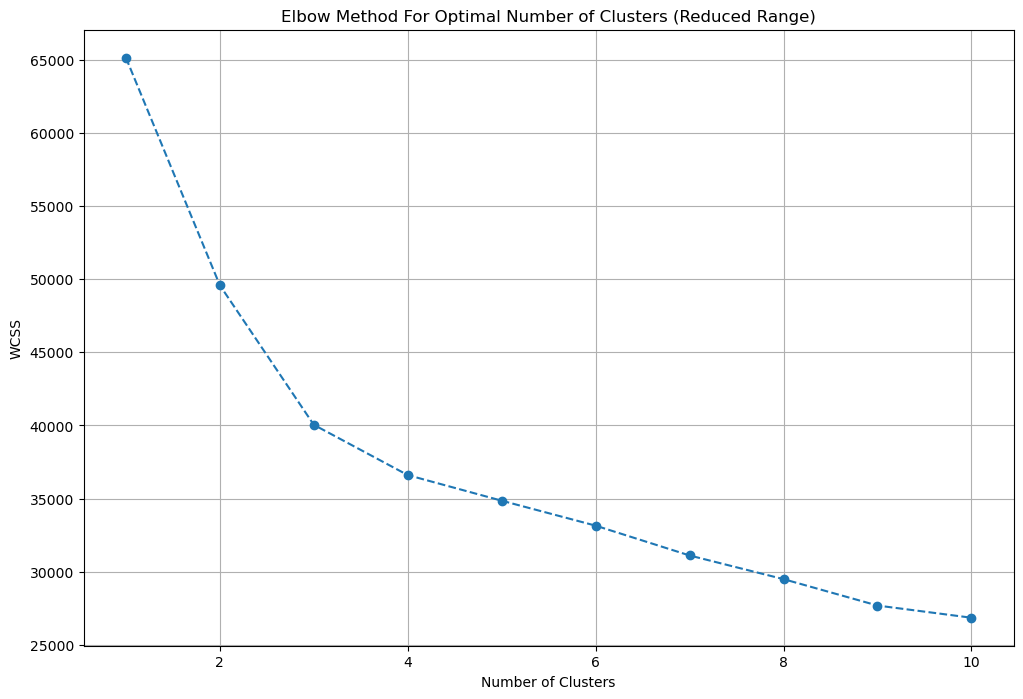

In [39]:
plt.figure(figsize=(12, 8))
plt.plot(range(1,11), wcss_reduced, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal Number of Clusters (Reduced Range)')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

In [41]:
n_clusters = 3

kmeans = KMeans(n_clusters=n_clusters, random_state=42)
kmeans.fit(scaled_data)
cluster_assignments = kmeans.predict(scaled_data)

In [45]:
df['furnishing_type'] = cluster_assignments

In [49]:
df.sample(5)[['furnishDetails','furnishing_type']]

,furnishDetails,furnishing_type
528,"['2 Wardrobe', '1 Water Purifier', '3 Fan', '2 Geyser', '1 Stove', '8 Light', '2 AC', '1 Chimney', '1 Modular Kitchen', 'No Bed', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Microwave', 'No Fridge', 'No Sofa', 'No TV', 'No Washing Machine']",0
1091,"['12 Fan', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Geyser', 'No Modular Kitchen', 'No Light', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']",2
821,NaN,2
569,[],2
294,"['1 Exhaust Fan', '1 Chimney', '1 Modular Kitchen', '3 Wardrobe', 'No AC', 'No Bed', 'No Curtains', 'No Dining Table', 'No Fan', 'No Geyser', 'No Light', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']",0


In [53]:
furnishings_df['furnishing_type'] = df['furnishing_type']
furnishings_df.groupby('furnishing_type').mean()

,AC,Modular Kitchen,Wardrobe,Microwave,Water Purifier,Dining Table,Chimney,Washing Machine,Fridge,Bed,Sofa,TV,Curtains,Geyser,Fan,Exhaust Fan,Stove,Light
furnishing_type,,,,,,,,,,,,,,,,,,
0,2.884913,0.902321,3.319149,0.070600,0.181818,0.019342,0.830754,0.011605,0.011605,0.058994,0.008704,0.057060,0.651838,2.874275,5.536750,0.866538,0.265957,13.104449
1,4.902439,0.907317,5.053659,0.824390,0.746341,0.473171,1.073171,0.707317,0.839024,1.595122,0.541463,1.307317,1.731707,4.365854,6.565854,0.863415,0.770732,13.014634
2,0.523529,0.144118,0.283613,0.002941,0.005042,0.003361,0.065966,0.000840,0.001681,0.019748,0.007143,0.005462,0.023109,0.142017,0.610924,0.052521,0.012605,1.235714
